# Hidden Markov Model regimes

- fits an HMM on 5 features: level, slope, curvature, BE5, policy spread (2Y minus EFFR)
- optimizes state count and covariance type on the 0.8 train split, evaluates with the held-out 0.2
- interprets the final 3-state model and computes real-time (non-smoothed) probabilities
- concepts explained in hmm_explained.md

In [1]:
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

In [2]:
#nelson siegel factors
ns = pd.read_csv("../data/ns.csv")
ns.rename(columns={"Beta 1": "level", "Beta 2": "slope", "Beta 3": "curvature"}, inplace=True)
ns["Date"] = pd.to_datetime(ns["Date"])
ns.set_index("Date", inplace=True)

#5 year breakeven inflation
BE5 = pd.read_csv("../data/T5YIE.csv").dropna()
BE5.rename(columns={"observation_date": "Date", "T5YIE": "BE5"}, inplace=True)
BE5["Date"] = pd.to_datetime(BE5["Date"])
BE5.set_index("Date", inplace=True)

#effective federal funds rate
EFFR = pd.read_csv("../data/EFFR.csv").dropna()
EFFR.rename(columns={"observation_date": "Date"}, inplace=True)
EFFR["Date"] = pd.to_datetime(EFFR["Date"])
EFFR.set_index("Date", inplace=True)

#2 year yield for the policy spread
df = pd.read_csv("../data/FRB_H15.csv").dropna()
df.rename(columns={"Series Description": "Date", "Market yield on U.S. Treasury securities at 2-year  constant maturity, quoted on investment basis": "2Y"}, inplace=True)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

rates = df[["2Y"]].merge(EFFR[["EFFR"]], left_index=True, right_index=True, how="left")
rates = rates.apply(pd.to_numeric, errors="coerce")
rates["policy_spread"] = rates["2Y"] - rates["EFFR"]

features = ["level", "slope", "curvature", "BE5", "policy_spread"]

combined = ns.merge(BE5[["BE5"]], left_index=True, right_index=True, how="left")
combined = combined.merge(rates[["policy_spread"]], left_index=True, right_index=True, how="left")
combined = combined[features].apply(pd.to_numeric, errors="coerce").dropna().sort_index()

#chronological 80/20 split, shuffling would destroy the time ordering an HMM needs
split = int(0.8 * len(combined))
trainDf = combined.iloc[:split]
testDf = combined.iloc[split:]

#scaler fit ONLY on training data, using fit_transform on test would leak information
scaler = StandardScaler()
xTrain = scaler.fit_transform(trainDf[features])
xTest = scaler.transform(testDf[features])

print("train: ", trainDf.index.min().date(), " to ", trainDf.index.max().date(), " (", len(trainDf), ")")
print("test:  ", testDf.index.min().date(), " to ", testDf.index.max().date(), " (", len(testDf), ")")

train:  2003-01-02  to  2021-09-08  ( 4672 )
test:   2021-09-09  to  2026-05-14  ( 1169 )


#### Parameter optimization

- grid: 2 to 5 states, diag and full covariance
- each candidate fit from 3 seeds, best training likelihood kept
- table reports train log likelihood, held-out log likelihood per observation, AIC, BIC
- prints the BIC pick and the held-out pick

In [3]:
def fitBestHmm(x, nStates, covarianceType):
    #fit from several seeds, keep the best converged training likelihood
    bestModel = None
    bestLogLikelihood = -np.inf

    for seed in [7, 21, 42]:
        candidate = GaussianHMM(
            n_components = nStates,
            covariance_type = covarianceType,
            n_iter = 500,
            tol = 1e-4,
            min_covar = 1e-4,
            random_state = seed,
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            candidate.fit(x)

        candidateLogLikelihood = candidate.score(x)
        if np.isfinite(candidateLogLikelihood) and candidateLogLikelihood > bestLogLikelihood:
            bestModel = candidate
            bestLogLikelihood = candidateLogLikelihood

    return bestModel


tuningRows = []
candidateModels = {}

for covarianceType in ["diag", "full"]:
    for nStates in range(2, 6):
        try:
            candidate = fitBestHmm(xTrain, nStates, covarianceType)
            candidateModels[(nStates, covarianceType)] = candidate
            tuningRows.append([
                nStates,
                covarianceType,
                candidate.score(xTrain),
                candidate.score(xTest) / len(xTest),
                candidate.aic(xTrain),
                candidate.bic(xTrain),
            ])
        except (ValueError, np.linalg.LinAlgError):
            #full covariance can go singular, record nothing and move on
            print("fit failed for ", nStates, " states ", covarianceType)

tuning = pd.DataFrame(tuningRows, columns=["nStates", "covarianceType", "trainLogLikelihood", "testLogLikelihoodPerObs", "aic", "bic"])
print(tuning.sort_values("bic").to_string(index=False))

bestBic = tuning.loc[tuning["bic"].idxmin()]
bestHeldOut = tuning.loc[tuning["testLogLikelihoodPerObs"].idxmax()]
print("\nBIC choice: ", int(bestBic["nStates"]), " states ", bestBic["covarianceType"])
print("held-out choice: ", int(bestHeldOut["nStates"]), " states ", bestHeldOut["covarianceType"])

Model is not converging.  Current: -4544.624806576741 is not greater than -4544.620929899656. Delta is -0.003876677084917901


Model is not converging.  Current: -4355.323449748795 is not greater than -4355.320610696434. Delta is -0.002839052360286587


Model is not converging.  Current: -8065.97150485351 is not greater than -8065.9714456983975. Delta is -5.915511246712413e-05


Model is not converging.  Current: -883.273933933371 is not greater than -883.2728808168373. Delta is -0.0010531165337397397


 nStates covarianceType  trainLogLikelihood  testLogLikelihoodPerObs          aic          bic
       5           full         -652.238963               -13.107728  1552.477927  2352.196400
       4           full        -3430.033496               -13.691845  7050.066993  7662.754532
       3           full        -4355.323468               -11.229145  8846.646935  9285.202227
       2           full       -11476.810891                -8.485512 23039.621782 23316.943510
       5           diag       -13652.682063               -10.782946 27453.364125 27930.615472
       4           diag       -16510.994616               -13.203510 33131.989231 33486.703070
       3           diag       -19779.424750               -13.437239 39634.849499 39879.924515
       2           diag       -24287.273303               -13.597231 48620.546606 48768.881484

BIC choice:  5  states  full
held-out choice:  2  states  full


#### Final model (3 states, diag)

- state means and standard deviations converted back to original units
- transition matrix and implied expected durations (1 / (1 - stay probability))

In [4]:
finalStates = 3
finalCovariance = "diag"
model = candidateModels[(finalStates, finalCovariance)]

#state means back in original units (the model was fit on standardized data)
stateMeans = pd.DataFrame(scaler.inverse_transform(model.means_), columns=features)
stateMeans.index.name = "state"
print("state means (original units):")
print(stateMeans.round(3).to_string())

#within state volatility, for the diag model the covariances are the per feature variances
stateVariances = np.asarray(model.covars_)
if stateVariances.ndim == 3:
    stateVariances = np.diagonal(stateVariances, axis1=1, axis2=2)
stateStd = pd.DataFrame(np.sqrt(stateVariances * (scaler.scale_ ** 2)), columns=features)
stateStd.index.name = "state"
print("\nstate standard deviations:")
print(stateStd.round(3).to_string())

#transition matrix and implied durations, expected duration = 1/(1 - stay probability)
transitionMatrix = pd.DataFrame(
    model.transmat_,
    index = ["from_state_" + str(i) for i in range(finalStates)],
    columns = ["to_state_" + str(i) for i in range(finalStates)],
)
print("\ntransition probabilities:")
print(transitionMatrix.round(4).to_string())

print("\nDuration in trading days")
for i in range(finalStates):
    stayProbability = model.transmat_[i][i]
    expectedDuration = 1.0 / (1.0 - stayProbability)
    print(" Expected duration of state " + str(i) + ": " + str(round(expectedDuration, 1)))

state means (original units):
       level  slope  curvature    BE5  policy_spread
state                                               
0      4.486 -2.432      0.255  1.952         -0.165
1      0.336  0.602      9.191  1.867          0.369
2     -3.259  3.775     18.354  1.712          0.690

state standard deviations:
       level  slope  curvature    BE5  policy_spread
state                                               
0      1.685  1.469      3.983  0.447          0.412
1      0.983  1.293      3.347  0.430          0.225
2      1.649  1.546      4.773  0.690          0.296

transition probabilities:
              to_state_0  to_state_1  to_state_2
from_state_0      0.9932      0.0068      0.0000
from_state_1      0.0070      0.9827      0.0104
from_state_2      0.0000      0.0097      0.9903

Duration in trading days
 Expected duration of state 0: 147.5
 Expected duration of state 1: 57.7
 Expected duration of state 2: 102.9


#### Decoded regimes and real-time probabilities

- decodes the full-sample regime path (retrospective) and lists the longest spells
- realTimeProbabilities: recomputes each test date's probability using only data through that date, plus a next-day forecast via the transition matrix
- cross-checks decoded regimes against official FOMC dates (never given to the model)
- plots the regime path and smoothed probabilities with the train/test split marked

longest decoded spells:
 state      start        end  tradingDays
     0 2022-10-20 2026-05-14          891
     0 2005-12-27 2008-03-17          555
     2 2008-09-12 2010-07-27          468
     2 2014-03-19 2015-09-28          385
     0 2018-12-14 2020-03-16          312
     0 2012-04-05 2013-06-06          293
     0 2020-03-30 2021-02-24          227
     1 2016-01-07 2016-11-17          218
     1 2017-03-17 2018-01-18          211
     2 2021-10-15 2022-07-20          190



most recent real-time probabilities:
            filtered_state_0  filtered_state_1  filtered_state_2
Date                                                            
2026-05-08               1.0               0.0               0.0
2026-05-11               1.0               0.0               0.0
2026-05-12               1.0               0.0               0.0
2026-05-13               1.0               0.0               0.0
2026-05-14               1.0               0.0               0.0

official event cross check:
      Date                                     event  decodedState
2008-12-16   FOMC established 0 to 1/4 percent range             2
2020-03-16 pandemic return to 0 to 1/4 percent range             0
2022-03-16                   tightening cycle begins             2
2023-07-26     target reaches 5-1/4 to 5-1/2 percent             0


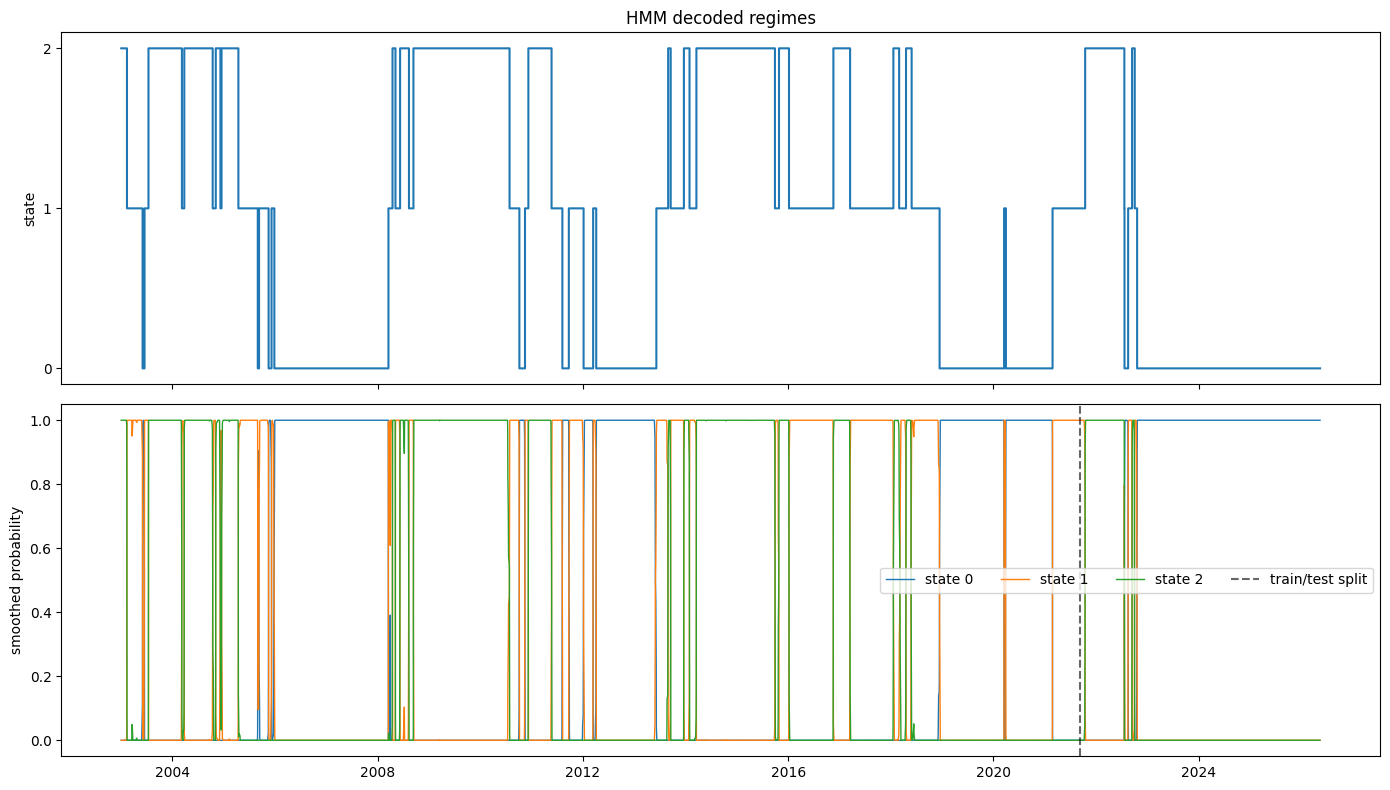

In [5]:
xAll = np.vstack([xTrain, xTest])
states = model.predict(xAll)

results = combined.copy()
results["state"] = states

#one row per consecutive regime spell
spellRows = []
start = 0
for end in range(1, len(states) + 1):
    if end == len(states) or states[end] != states[start]:
        spellRows.append([int(states[start]), results.index[start], results.index[end - 1], end - start])
        start = end
spells = pd.DataFrame(spellRows, columns=["state", "start", "end", "tradingDays"])

print("longest decoded spells:")
print(spells.sort_values("tradingDays", ascending=False).head(10).to_string(index=False))


def realTimeProbabilities(model, xTrain, xTest):
    #each test date probability uses only data through that date
    history = xTrain.copy()
    filtered = []
    nextDay = []
    for observation in xTest:
        history = np.vstack([history, observation.reshape(1, -1)])
        probabilityToday = model.predict_proba(history)[-1]
        filtered.append(probabilityToday)
        nextDay.append(probabilityToday @ model.transmat_)
    return np.asarray(filtered), np.asarray(nextDay)

filteredProbs, nextDayProbs = realTimeProbabilities(model, xTrain, xTest)
realTime = pd.DataFrame(filteredProbs, index=testDf.index,
                        columns=["filtered_state_" + str(i) for i in range(finalStates)])
print("\nmost recent real-time probabilities:")
print(realTime.tail(5).round(4).to_string())

#official FOMC dates as an after the fact cross check, these were never given to the model
officialEvents = pd.DataFrame([
    ["2008-12-16", "FOMC established 0 to 1/4 percent range"],
    ["2020-03-16", "pandemic return to 0 to 1/4 percent range"],
    ["2022-03-16", "tightening cycle begins"],
    ["2023-07-26", "target reaches 5-1/4 to 5-1/2 percent"],
], columns=["Date", "event"])
officialEvents["Date"] = pd.to_datetime(officialEvents["Date"])

decodedStates = []
for i in range(len(officialEvents)):
    available = results.loc[results.index <= officialEvents["Date"].iloc[i]]
    decodedStates.append(int(available.iloc[-1]["state"]))
officialEvents["decodedState"] = decodedStates
print("\nofficial event cross check:")
print(officialEvents.to_string(index=False))

#plot the decoded regime path and the smoothed probabilities
smoothedProbs = model.predict_proba(xAll)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].step(results.index, results["state"], where="post")
axes[0].set_ylabel("state")
axes[0].set_yticks(range(finalStates))
axes[0].set_title("HMM decoded regimes")
for i in range(finalStates):
    axes[1].plot(results.index, smoothedProbs[:, i], label="state " + str(i), linewidth=1)
axes[1].axvline(testDf.index[0], color="black", linestyle="--", alpha=0.6, label="train/test split")
axes[1].set_ylabel("smoothed probability")
axes[1].legend(ncol=4)
plt.tight_layout()
plt.show()

#### Findings summary

- **Setup.** Five features (level, slope, curvature, BE5, policy spread); 4,672 training observations (2003-01 to 2021-09) and 1,169 held-out observations (2021-09 to 2026-05); the scaler is fit on the training sample only.
- **Covariance structure.** Full-covariance specifications dominate diagonal specifications on all in-sample criteria (training log likelihood, AIC, and BIC), consistent with correlation among the five features within a regime. Out of sample the ranking is not uniform: the 2-state full model attains the best held-out score (-8.49 per observation), while the 5-state diagonal model (-10.78) outranks the 4- and 5-state full models.
- **Model selection.** BIC selects 5 states (full); the held-out score selects 2 states (full). This disagreement indicates genuine uncertainty in the state count, so the pre-committed specification (3 states, diagonal, comparable with the HSMM notebook) is retained and the grid serves as a sensitivity analysis. The 5-state full model combines the best training likelihood (-652 versus -4,355 for 3-state full) with a mediocre held-out score, a characteristic overfitting pattern.
- **Regime interpretation.** State means are ns.csv beta values and are interpreted relatively. State 0 corresponds to high-rate periods (2005 to 2008, and 2022-10 to the present, the longest decoded spell at 891 trading days); state 2 to easing and post-crisis periods (2008 to 2010, 2014 to 2015, the 2021 to 2022 transition); state 1 to intermediate conditions.
- **Persistence.** Stay probabilities range from 0.983 to 0.993, implying expected durations of 148, 58, and 103 trading days.
- **Duration misfit.** Decoded spells run several times longer than the implied geometric durations (891 and 555 days against an implied 148 for state 0). This misfit is the empirical motivation for the explicit-duration HSMM.
- **External validation.** Decoded regime boundaries align with FOMC actions never supplied to the model: the 2018 to 2020 state-0 spell ends on 2020-03-16 (the emergency cut), 2008-12-16 falls in easing state 2, and 2023-07-26 falls in high-rate state 0.
- **Real-time inference.** Filtered probabilities currently assign approximately 100% to state 0. Only the filtered path is admissible as a forecasting input; the smoothed output above is retrospective description.
- **Numerical note.** The non-convergence messages during tuning reflect log-likelihood changes of order 0.001 at the stopping threshold and do not indicate fitting failure.